In [1]:
pip install mysql-connector-python


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd

import mysql.connector

import os



# List of CSV files and their corresponding table names

csv_files = [

    ('customers.csv', 'customers'),

    ('orders.csv', 'orders'),

    ('sellers.csv', 'sellers'),

    ('products.csv', 'products'),

    ('geolocation.csv', 'geolocation'),

    ('payments.csv', 'payments') ,

    ('order_items.csv','order_items')# Added payments.csv for specific handling

]



# Connect to the MySQL database

conn = mysql.connector.connect(

    host='localhost',

    user='root',

    password='(Shehzad1514$)',

    database='ecommerce'

)

cursor = conn.cursor()



# Folder containing the CSV files

folder_path = r'C:\Users\aaa\Downloads\Ecommerce data (python and SQL'



def get_sql_type(dtype):

    if pd.api.types.is_integer_dtype(dtype):

        return 'INT'

    elif pd.api.types.is_float_dtype(dtype):

        return 'FLOAT'

    elif pd.api.types.is_bool_dtype(dtype):

        return 'BOOLEAN'

    elif pd.api.types.is_datetime64_any_dtype(dtype):

        return 'DATETIME'

    else:

        return 'TEXT'



for csv_file, table_name in csv_files:

    file_path = os.path.join(folder_path, csv_file)

   

    # Read the CSV file into a pandas DataFrame

    df = pd.read_csv(file_path)

   

    # Replace NaN with None to handle SQL NULL

    df = df.where(pd.notnull(df), None)

   

    # Debugging: Check for NaN values

    print(f"Processing {csv_file}")

    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")



    # Clean column names

    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]



    # Generate the CREATE TABLE statement with appropriate data types

    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])

    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'

    cursor.execute(create_table_query)



    # Insert DataFrame data into the MySQL table

    for _, row in df.iterrows():

        # Convert row to tuple and handle NaN/None explicitly

        values = tuple(None if pd.isna(x) else x for x in row)

        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"

        cursor.execute(sql, values)



    # Commit the transaction for the current CSV file

    conn.commit()



# Close the connection

conn.close()

Processing customers.csv
NaN values before replacement:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Processing orders.csv
NaN values before replacement:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Processing sellers.csv
NaN values before replacement:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Processing products.csv
NaN values before replacement:
product_id                      0
product category              610
product_name_length           610
product_description_length    610
product_photos_qty            610
prod

In [58]:
import pandas as pd
import numpy as np
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns

db = mysql.connector.connect(
    host='localhost',
    user='root',
    password='(Shehzad1514$)',
    database='ecommerce'    )
cursor = db.cursor()

 1. List all unique cities where customers are located.

In [24]:
query = '''SELECT DISTINCT customer_city FROM customers'''
cursor.execute(query)
customer_cities = cursor.fetchall()
df = pd.DataFrame(customer_cities, columns=['customer_city'])
print(df.head())


           customer_city
0                 franca
1  sao bernardo do campo
2              sao paulo
3        mogi das cruzes
4               campinas


2. Count the number of orders placed in 2017.

In [23]:
query = '''SELECT COUNT(order_id) FROM orders WHERE year(order_purchase_timestamp) = '2017' '''
cursor.execute(query)
data = cursor.fetchall()
'Total orders in 2017:' + str(data[0][0])



'Total orders in 2017:45101'

3. Find the total sales per category.

In [9]:
query = '''SELECT COUNT(order_id) FROM orders WHERE year(order_purchase_timestamp) = '2017' '''
cursor.execute(query)
data = cursor.fetchall()
'Total orders in 2017:' + str(data[0][0])




'Total orders in 2017:45101'

In [26]:
query = '''SELECT 
    p.product_category, 
    SUM(pay.payment_value) AS current_year_sales
FROM ecommerce.products AS p 
JOIN ecommerce.order_items AS o 
    ON p.product_id = o.product_id 
JOIN ecommerce.payments AS pay 
    ON o.order_id = pay.order_id
GROUP BY p.product_category'''

cursor.execute(query)
data = cursor.fetchall()

df = pd.DataFrame(data, columns=['product_category', 'current_year_sales'])
# Capitalize the first letter of every word
df['product_category'] = df['product_category'].str.title()

# Take a look at the result
df

,product_category,current_year_sales
0,Perfumery,5.067387e+05
1,Furniture Decoration,1.430176e+06
2,Telephony,4.868821e+05
3,Bed Table Bath,1.712554e+06
4,Automotive,8.522943e+05
...,...,...
69,Cds Music Dvds,1.199430e+03
70,La Cuisine,2.913530e+03
71,Fashion Children'S Clothing,7.856700e+02
72,Pc Gamer,2.174430e+03


4. Calculate the percentage of orders that were paid in installments.

In [27]:
# Use clear, uppercase SQL syntax and descriptive alias naming conventions
query = """
SELECT 
    (COUNT(DISTINCT CASE WHEN payment_installments > 1 THEN order_id END) * 100.0) 
    / COUNT(DISTINCT order_id) AS pct_installment_orders
FROM 
    ecommerce.payments;
"""

try:
    cursor.execute(query)
    # Using fetchone() because an aggregate query without a GROUP BY always returns a single row
    result = cursor.fetchone()
    
    # Format cleanly for presentation/logging
    percentage = result[0] if result else 0.0
    print(f"Percentage of orders paid in installments: {percentage:.2f}%")

except Exception as e:
    print(f"Database query failed: {e}")

Percentage of orders paid in installments: 51.46%


5. Count the number of customers from each state. 


In [29]:
query = '''SELECT 
    customer_state, 
    COUNT(customer_id) AS customer_count
FROM 
    ecommerce.customers
GROUP BY 
    customer_state
ORDER BY 
    customer_count DESC;'''
cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns=['customer_state', 'customer_count'])
df.head()

,customer_state,customer_count
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045


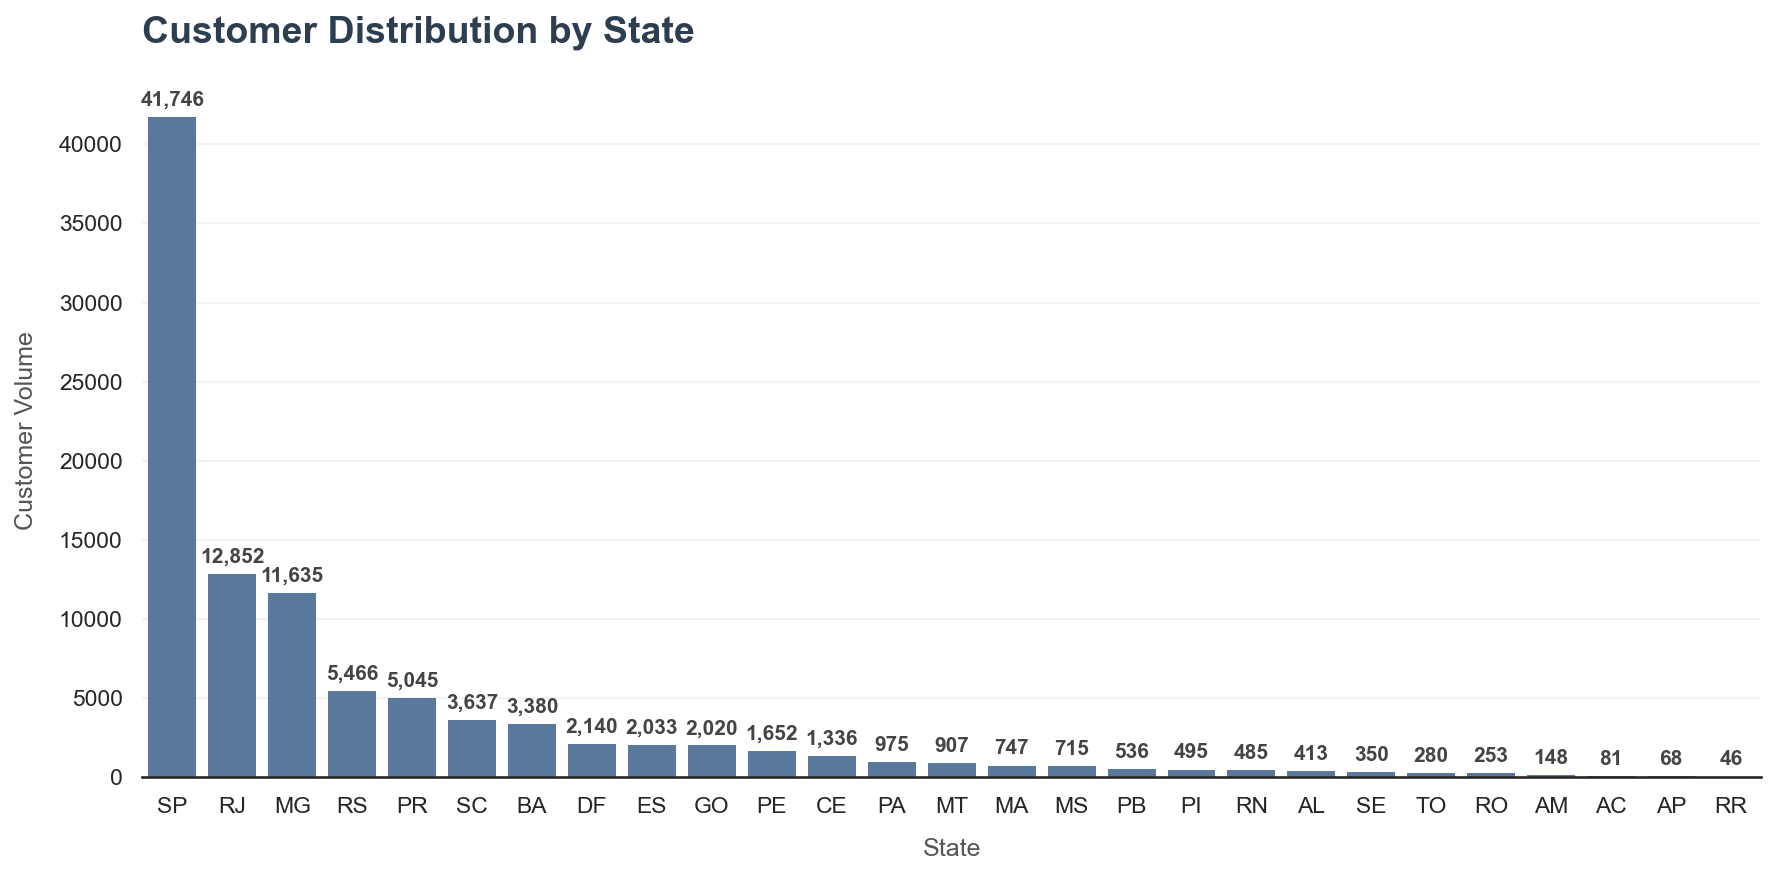

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preparation: Sort data descending to establish immediate visual hierarchy
df_sorted = df.sort_values(by='customer_count', ascending=False)

# Figure Setup: High DPI for presentation-grade sharpness, clean aspect ratio
plt.figure(figsize=(12, 6), dpi=150)

# Styling Config: Use a clean white style and a professional corporate color palette
sns.set_theme(style="white")
tableau_blue = "#4e79a7" # Exact Tableau default blue

# Create Barplot
ax = sns.barplot(
    x='customer_state', 
    y='customer_count', 
    data=df_sorted, 
    color=tableau_blue, # Single tone prevents rainbow cognitive overload
    edgecolor="none"
)

# Title & Typography (Clear visual hierarchy)
plt.title("Customer Distribution by State", fontsize=18, fontweight='bold', pad=20, loc='left', color='#2c3e50')
plt.xlabel("State", fontsize=12, labelpad=10, color='#555555')
plt.ylabel("Customer Volume", fontsize=12, labelpad=10, color='#555555')

# Clean Spines (The "Data-Ink Ratio" Rule)
sns.despine(left=True, bottom=False) # Remove unnecessary borders

# Clean up axes & add faint horizontal guidelines
ax.yaxis.grid(True, linestyle='-', which='major', color='#f0f0f0', alpha=0.8)
ax.set_axisbelow(True) # Push grid lines behind the data bars

# Executive Request: Add direct data values on top of bars if the dataset is small/medium
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height()):,}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', 
                    fontsize=10, color='#444444', fontweight='semibold')

plt.tight_layout()
plt.show()

1. Calculate the number of orders per month in 2018.

In [31]:
query = '''SELECT 
    DATE_FORMAT(order_purchase_timestamp, '%m') AS order_month,
    COUNT(order_id) AS total_orders
FROM 
    ecommerce.orders
WHERE 
    YEAR(order_purchase_timestamp) = 2018
GROUP BY 
    order_month
ORDER BY 
    order_month 
;'''
cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns=['order_month', 'total_orders'])


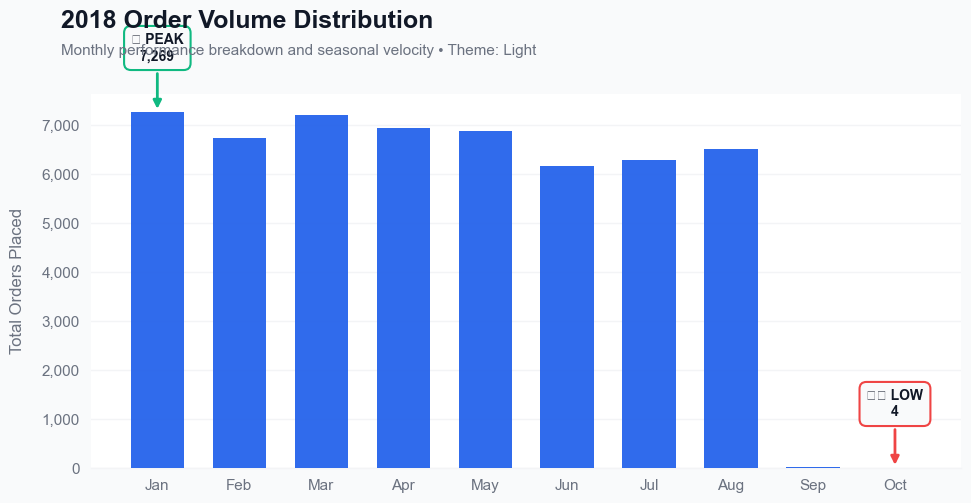

In [2]:

# ==========================================
# 1. THEME CONFIGURATION (Toggle Light/Dark)
# ==========================================
THEME = "light"  # Options: 'light' or 'dark'

if THEME == "light":
    BG_COLOR = "#FFFFFF"      # Clean white plotting canvas
    PAPER_COLOR = "#F9FAFB"   # Subtle off-white surrounding background
    BAR_COLOR = "#2563EB"     # Deep corporate electric blue
    GRID_COLOR = "#F3F4F6"    # Ultra-faint gray horizontal gridlines
    TEXT_MAIN = "#111827"     # Dark gray/black for crisp typography
    TEXT_MUTED = "#6B7280"    # Medium gray for subtitles and axis labels
    PEAK_COLOR = "#10B981"    # Emerald green accent for Peak
    LOW_COLOR = "#EF4444"     # Coral red accent for Low
else:
    BG_COLOR = "#0F172A"      # Deep Enterprise Slate canvas
    PAPER_COLOR = "#1E293B"   # Dark container frame background
    BAR_COLOR = "#38BDF8"     # Vibrant luminous cyan bar fill
    GRID_COLOR = "#334155"    # Faint steel-blue horizontal gridlines
    TEXT_MAIN = "#F9FAFB"     # Off-white for high contrast typography
    TEXT_MUTED = "#94A3B8"    # Slate gray for subtitles and axis labels
    PEAK_COLOR = "#34D399"    # Bright emerald for Peak (dark mode)
    LOW_COLOR = "#F87171"     # Bright coral for Low (dark mode)


# ==========================================
# 2. DATASET INTEGRATION & METRICS
# ==========================================
actual_sql_data = [
    ('01', 7269), ('02', 6728), ('03', 7211), ('04', 6939), ('05', 6873),
    ('06', 6167), ('07', 6292), ('08', 6512), ('09', 16),   ('10', 4)
]

df = pd.DataFrame(actual_sql_data, columns=['order_month', 'total_orders'])

month_map = {
    "01": "Jan", "02": "Feb", "03": "Mar", "04": "Apr", "05": "May", 
    "06": "Jun", "07": "Jul", "08": "Aug", "09": "Sep", "10": "Oct"
}
df["month_name"] = df["order_month"].map(month_map)

# Pinpoint critical indices dynamically
peak_idx = df["total_orders"].idxmax()
low_idx = df["total_orders"].idxmin()

peak_month = df.loc[peak_idx, "month_name"]
peak_val = df.loc[peak_idx, "total_orders"]

low_month = df.loc[low_idx, "month_name"]
low_val = df.loc[low_idx, "total_orders"]


# ==========================================
# 3. CANVAS CONFIGURATION & GRAPHICS
# ==========================================
# Use system UI typefaces for an ultra-clean corporate finish
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Inter', 'Arial', 'Segoe UI', 'DejaVu Sans']

# Replicating paper_bgcolor vs plot_bgcolor split
fig, ax = plt.subplots(figsize=(10, 5.5), facecolor=PAPER_COLOR)
ax.set_facecolor(BG_COLOR)

# Generate bars using crisp, clean dimensions (Seaborn color application)
bars = ax.bar(
    df["month_name"], 
    df["total_orders"], 
    color=BAR_COLOR, 
    width=0.65, 
    edgecolor='none', 
    alpha=0.95,
    zorder=3  # Forces bars to sit firmly on top of grid lines
)

# Layer structural guidelines down behind data markers
ax.set_axisbelow(True)
ax.yaxis.grid(True, color=GRID_COLOR, linestyle='-', linewidth=1, zorder=0)
ax.xaxis.grid(False)

# Strip out unnecessary framing layout lines
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color(GRID_COLOR)
ax.spines['bottom'].set_linewidth(1)


# ==========================================
# 4. TYPOGRAPHY & LABEL ARCHITECTURE
# ==========================================
# Configure Tick Layout & Spacing
ax.tick_params(axis='x', colors=TEXT_MUTED, labelsize=11, length=0, pad=8)
ax.tick_params(axis='y', colors=TEXT_MUTED, labelsize=11, length=0, pad=8)

# Format large metrics seamlessly with thousands commas
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))

# Axis Titles
ax.set_ylabel("Total Orders Placed", color=TEXT_MUTED, fontsize=12, fontweight='medium', labelpad=12)


# ==========================================
# 5. CALLOUT ANNOTATIONS (Peak & Low Labels)
# ==========================================
# Styling dictionaries for custom bounding card layers
peak_bbox = dict(boxstyle="round,pad=0.5", facecolor=PAPER_COLOR, edgecolor=PEAK_COLOR, linewidth=1.5)
low_bbox = dict(boxstyle="round,pad=0.5", facecolor=PAPER_COLOR, edgecolor=LOW_COLOR, linewidth=1.5)

# Peak Label Configuration (Matches Plotly's pixel-offset layout approach)
ax.annotate(
    f"👑 PEAK\n{peak_val:,}",
    xy=(peak_month, peak_val),
    xytext=(0, 35),
    textcoords="offset points",
    ha='center', va='bottom',
    color=TEXT_MAIN, fontsize=10, fontweight='bold',
    bbox=peak_bbox,
    arrowprops=dict(arrowstyle="-|>", color=PEAK_COLOR, linewidth=2, mutation_scale=12),
    zorder=5
)

# Low Label Configuration
ax.annotate(
    f"⚠️ LOW\n{low_val:,}",
    xy=(low_month, low_val),
    xytext=(0, 35),
    textcoords="offset points",
    ha='center', va='bottom',
    color=TEXT_MAIN, fontsize=10, fontweight='bold',
    bbox=low_bbox,
    arrowprops=dict(arrowstyle="-|>", color=LOW_COLOR, linewidth=2, mutation_scale=12),
    zorder=5
)


# ==========================================
# 6. HEADER TITLES & RENDER PACKAGING
# ==========================================
# Formatted Title Group using coordinate text stamps (prevents text clipping)
fig.text(
    0.05, 0.92, "2018 Order Volume Distribution", 
    fontsize=18, fontweight='bold', color=TEXT_MAIN, ha='left'
)
fig.text(
    0.05, 0.87, f"Monthly performance breakdown and seasonal velocity • Theme: {THEME.title()}", 
    fontsize=11, color=TEXT_MUTED, ha='left'
)

# Clean, specific boundaries defining internal padding bounds
plt.subplots_adjust(left=0.08, right=0.95, top=0.80, bottom=0.12)

plt.show()

 2. Find the average number of products per order, grouped by customer city.

In [40]:
query = '''SELECT 
    c.customer_city,
    COUNT(oi.product_id) * 1.0 / COUNT(DISTINCT o.order_id) AS avg_products_per_order
FROM 
    ecommerce.customers c
JOIN 
    ecommerce.orders o ON c.customer_id = o.customer_id
JOIN 
    ecommerce.order_items oi ON o.order_id = oi.order_id
GROUP BY 
    c.customer_city
ORDER BY 
    avg_products_per_order DESC
;'''
cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns=['customer_city', 'avg_products_per_order'])    
df.head(10)

,customer_city,avg_products_per_order
0,padre carvalho,7.00000
1,celso ramos,6.50000
2,candido godoi,6.00000
3,datas,6.00000
4,matias olimpio,5.00000
5,cidelandia,4.00000
6,curralinho,4.00000
7,morro de sao paulo,4.00000
8,picarra,4.00000
9,teixeira soares,4.00000


3. Calculate the percentage of total revenue contributed by each product category.

In [ ]:
query = '''SELECT 
    p.product_category,
    ROUND(SUM(pay.payment_value), 2) AS category_revenue,
    ROUND((SUM(pay.payment_value) * 100.0) / (SELECT SUM(payment_value) FROM ecommerce.payments), 2) AS revenue_percentage
FROM 
    ecommerce.payments pay
-- Added this join to bridge payments and products
JOIN 
    ecommerce.order_items oi ON pay.order_id = oi.order_id
JOIN 
    ecommerce.products p ON oi.product_id = p.product_id
GROUP BY 
    p.product_category
ORDER BY 
    revenue_percentage DESC
LIMIT 1000;'''
cursor.execute(query)
data = cursor.fetchall()
df = pd.DataFrame(data, columns=['product_category', 'category_revenue', 'revenue_percentage'])    
df.head()


,product_category,category_revenue,revenue_percentage
0,bed table bath,1712553.67,10.70
1,HEALTH BEAUTY,1657373.12,10.35
2,computer accessories,1585330.45,9.90
3,Furniture Decoration,1430176.39,8.93
4,Watches present,1429216.68,8.93


4. Identify the correlation between product price and the number of times a product has been purchased.

In [ ]:

# We let SQL do the heavy JOIN and initial grouping, but preserve row-level granularity
query = """
SELECT 
    COALESCE(p.product_category, 'Uncategorized') AS category,
    oi.product_id,
    AVG(oi.price) AS price,
    COUNT(oi.order_id) AS purchase_count
FROM 
    ecommerce.order_items oi
LEFT JOIN 
    ecommerce.products p ON oi.product_id = p.product_id
GROUP BY 
    1, 2;
"""

cursor.execute(query)
data = cursor.fetchall() 

# Load data into a rich DataFrame
df = pd.DataFrame(data, columns=['category', 'product_id', 'price', 'purchase_count'])

# --- SIMPLE & EASY CORRELATION CHECK ---

# 1. Clear out any rows with missing data just in case
df_clean = df.dropna(subset=['price', 'purchase_count'])

# 2. Compute the Pearson correlation coefficient
pandas_corr = df_clean['price'].corr(df_clean['purchase_count'])

# 3. NumPy sanity check cross-verification
numpy_corr = np.corrcoef(df_clean['price'].values, df_clean['purchase_count'].values)[0, 1]

# Display baseline execution results
print(df_clean.head())
print("-" * 50)
print(f"Calculated Pearson Correlation Matrix Value (r): {pandas_corr:.4f}")
print(f"NumPy Precision Verification Check       (r): {numpy_corr:.4f}")
print("-" * 50)

# --- PROFESSIONAL SENIOR ANALYST INTERPRETATION ---
# Evaluates the strength and direction of the linear relationship based on standard statistical thresholds

r = pandas_corr
abs_r = abs(r)

if abs_r < 0.1:
    strength = "negligible or no meaningful"
    direction = ""
    business_takeaway = "Price variations do not show a clear linear pattern with unit sales volume across the global inventory catalog."
elif abs_r < 0.3:
    strength = "a weak"
    direction = "negative" if r < 0 else "positive"
    business_takeaway = f"There is a slight structural tendency pointing toward a {direction} relationship, but price is likely not the dominant driver of purchase frequency."
elif abs_r < 0.5:
    strength = "a moderate"
    direction = "negative (inverse)" if r < 0 else "positive (direct)"
    business_takeaway = f"Changes in product pricing show a clear, measurable {direction} relationship with sales velocity across the platform."
else:
    strength = "a strong"
    direction = "negative (highly price-sensitive)" if r < 0 else "positive"
    business_takeaway = f"Purchasing behavior is highly dependent on price point. The data signals clear {direction} linear elasticity."

# Format direction text for clean printing
direction_text = f" {direction}" if direction else ""

print("SENIOR ANALYSIS REVIEW SUMMARY:")
print(f"• Metric Verdict: Detected {strength}{direction_text} linear correlation.")
print(f"• Executive Takeaway: {business_takeaway}")
print("-" * 50)

        category                        product_id       price  purchase_count
0  HEALTH BEAUTY  310ae3c140ff94b03219ad0adc3c778f  145.949997               2
1  sport leisure  8cab8abac59158715e0d70a36c807415   99.900002               2
2  sport leisure  b50c950aba0dcead2c48032a690ce817   99.000000               4
3     Cool Stuff  5ed9eaf534f6936b51d0b6c5e4d5c2e9   24.982857              21
4  sport leisure  35537536ed2b4c561b4018bf3abf54e0  382.307692              13
--------------------------------------------------
Calculated Pearson Correlation Matrix Value (r): -0.0321
NumPy Precision Verification Check       (r): -0.0321
--------------------------------------------------
SENIOR ANALYSIS REVIEW SUMMARY:
• Metric Verdict: Detected negligible or no meaningful linear correlation.
• Executive Takeaway: Price variations do not show a clear linear pattern with unit sales volume across the global inventory catalog.
--------------------------------------------------


5. Calculate the total revenue generated by each seller, and rank them by revenue.

In [42]:
query = """
SELECT 
    oi.seller_id,
    ROUND(SUM(pay.payment_value), 2) AS total_revenue,
    RANK() OVER (ORDER BY SUM(pay.payment_value) DESC) AS seller_rank
FROM 
    ecommerce.order_items oi
JOIN 
    ecommerce.payments pay ON oi.order_id = pay.order_id
JOIN 
    ecommerce.orders o ON oi.order_id = o.order_id -- Added this missing join
WHERE 
    o.order_status NOT IN ('canceled', 'unavailable')
GROUP BY 
    oi.seller_id
ORDER BY 
    seller_rank ASC
LIMIT 1000;
"""

cursor.execute(query)
data = cursor.fetchall() 
df = pd.DataFrame(data, columns=['seller_id', 'total_revenue', 'seller_rank'])
df.head(10)


,seller_id,total_revenue,seller_rank
0,7c67e1448b00f6e969d365cea6b010ab,507166.91,1
1,1025f0e2d44d7041d6cf58b6550e0bfa,308222.04,2
2,4a3ca9315b744ce9f8e9374361493884,301064.61,3
3,1f50f920176fa81dab994f9023523100,290185.92,4
4,53243585a1d6dc2643021fd1853d8905,284903.08,5
5,da8622b14eb17ae2831f4ac5b9dab84a,272219.32,6
6,4869f7a5dfa277a7dca6462dcf3b52b2,263918.86,7
7,955fee9216a65b617aa5c0531780ce60,236302.52,8
8,fa1c13f2614d7b5c4749cbc52fecda94,205290.17,9
9,7e93a43ef30c4f03f38b393420bc753a,181218.58,10


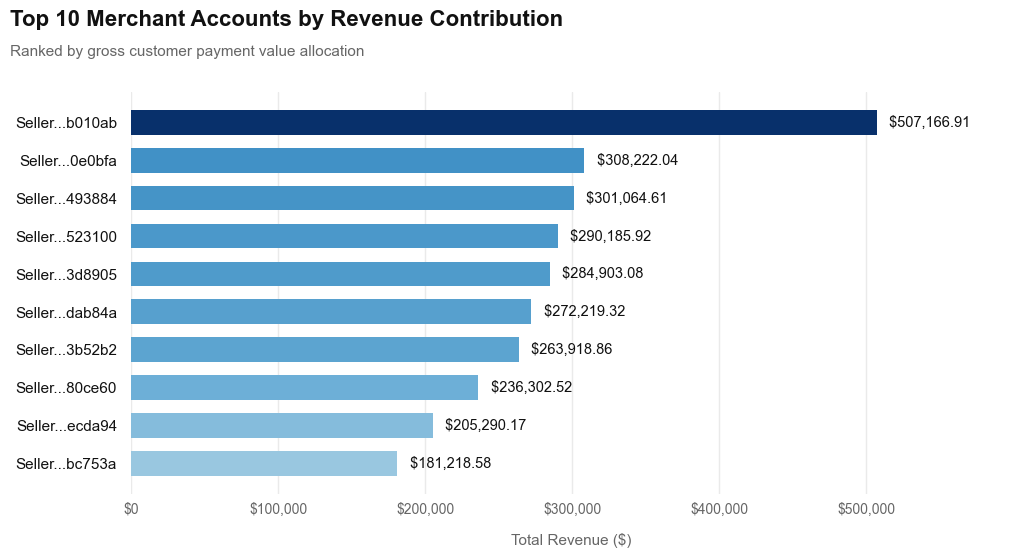

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import seaborn as sns

# --- Mock Data Shell (Replace this with your actual 'df') ---
# data = {'seller_id': [f"hash_id_xyz_{i}" for i in range(10)], 'total_revenue': [152000, 140000, 115000, 95000, 82000, 76000, 50000, 43000, 12000, 5500]}
# df = pd.DataFrame(data)
# ------------------------------------------------------------

# ==================================================================
# 1. DATA PREPARATION & UX PROCESSING
# ==================================================================
plot_df = df.head(10).copy()

# UX FIX: Truncate long seller ID hashes so they don't crowd the Y-axis
plot_df['display_id'] = plot_df['seller_id'].apply(
    lambda x: f"Seller...{str(x)[-6:]}" if len(str(x)) > 10 else str(x)
)

# UX FIX: Sort ascending so the #1 top earner displays at the top of a horizontal chart
plot_df = plot_df.sort_values(by='total_revenue', ascending=True)


# ==================================================================
# 2. DESIGN SYSTEM & COLOR GRADIENT CONFIGURATION
# ==================================================================
# Premium Typography Config
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Inter', 'Segoe UI', 'DejaVu Sans']

fig, ax = plt.subplots(figsize=(11, 6), facecolor='white')
ax.set_facecolor('white')

# Vectorized color mapping logic (maps revenue value into the 'Blues' palette)
# We set vmin slightly below 0 so the lowest revenue bar remains clearly visible against white
norm = mcolors.Normalize(
    vmin=plot_df['total_revenue'].min() * -0.15, 
    vmax=plot_df['total_revenue'].max()
)
bar_colors = plt.cm.Blues(norm(plot_df['total_revenue'].values))


# ==================================================================
# 3. GRAPHICAL CONSTRUCTION & DATA MARGINS
# ==================================================================
bars = ax.barh(
    plot_df['display_id'],
    plot_df['total_revenue'],
    color=bar_colors,
    edgecolor='none',
    height=0.65,
    zorder=3
)

# Dynamic Margin Padding: Create 18% extra space on the right edge 
# so outside data labels never clip past the edge of the figure frame
ax.set_xlim(0, plot_df['total_revenue'].max() * 1.18)


# ==================================================================
# 4. TYPOGRAPHY, AXIS FORMATTING & GRIDLINES
# ==================================================================
# Set up crisp x-axis currency tick labels
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"${x:,.0f}"))
ax.tick_params(axis='x', colors='#666666', labelsize=10, length=0, pad=6)
ax.tick_params(axis='y', colors='#111111', labelsize=11, length=0, pad=10)

# Structural Grid System (X-axis grid lines tucked neatly behind data layers)
ax.set_axisbelow(True)
ax.xaxis.grid(True, color='#EAEAEA', linestyle='-', linewidth=1, zorder=0)
ax.yaxis.grid(False)

# Strip down box framing lines for a modern minimalist style
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

# X-Axis Title Block
ax.set_xlabel("Total Revenue ($)", color='#666666', fontsize=11, labelpad=12)


# ==================================================================
# 5. OUTSIDE DATA LABELS (Emulating Plotly Text System)
# ==================================================================
# Dynamically map formatted strings perfectly adjacent to each bar point
ax.bar_label(
    bars, 
    labels=[f" ${x:,.2f}" for x in plot_df['total_revenue']], 
    padding=6, 
    color='#111111', 
    fontsize=10.5,
    fontweight='medium'
)


# ==================================================================
# 6. HEADER ARCHITECTURE & RENDER PACKAGING
# ==================================================================
# Coordinate-anchored Title Group to completely prevent subtitle overlapping
fig.text(
    0.04, 0.93, "Top 10 Merchant Accounts by Revenue Contribution", 
    fontsize=16, fontweight='bold', color='#111111', ha='left'
)
fig.text(
    0.04, 0.88, "Ranked by gross customer payment value allocation", 
    fontsize=11, color='#666666', ha='left'
)

# Apply specific margins around the axis bounding area
plt.subplots_adjust(left=0.15, right=0.95, top=0.82, bottom=0.15)

plt.show()

1. Calculate the moving average of order values for each customer over their order history.


In [44]:
# Step 1: Write a ultra-lightweight query without ANY sorting or window functions
query = """
WITH aggregated_payments AS (
    SELECT 
        order_id,
        SUM(payment_value) AS total_order_value
    FROM 
        ecommerce.payments
    GROUP BY 
        order_id
)
SELECT 
    c.customer_unique_id,
    o.order_id,
    o.order_purchase_timestamp,
    p.total_order_value AS current_order_value
FROM 
    ecommerce.orders o
JOIN 
    ecommerce.customers c ON o.customer_id = c.customer_id
JOIN 
    aggregated_payments p ON o.order_id = p.order_id
WHERE 
    o.order_status = 'delivered';
"""

# Step 2: Execute and fetch raw data streams directly into Python memory
cursor.execute(query)
data = cursor.fetchall()

# Step 3: Load into DataFrame
df = pd.DataFrame(data, columns=[
    'customer_unique_id', 
    'order_id', 
    'order_purchase_timestamp', 
    'current_order_value'
])

# ------------------------------------------------------------------
# PANDAS REAL-TIME PROCESSING ENGINE (Bypasses C:\ Windows Temp Disk)
# ------------------------------------------------------------------

# 4. Cast timestamp string explicitly to a datetime object
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# 5. Sort the dataset chronologically per customer inside RAM
df = df.sort_values(by=['customer_unique_id', 'order_purchase_timestamp']).reset_index(drop=True)

# 6. Compute the 3-Order Rolling Moving Average using a high-speed vector transform
df['rolling_avg_3_orders'] = (
    df.groupby('customer_unique_id')['current_order_value']
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    .round(2)
)

# Clean up decimal column rendering
df['current_order_value'] = df['current_order_value'].round(2)

# Display executive confirmation matrix
df.head()

,customer_unique_id,order_id,order_purchase_timestamp,current_order_value,rolling_avg_3_orders
0,0000366f3b9a7992bf8c76cfdf3221e2,e22acc9c116caa3f2b7121bbb380d08e,2018-05-10 10:56:27,141.90,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3594e05a005ac4d06a72673270ef9ec9,2018-05-07 11:11:27,27.19,27.19
2,0000f46a3911fa3c0805444483337064,b33ec3b699337181488304f362a6b734,2017-03-10 21:05:03,86.22,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,41272756ecddd9a9ed0180413cc22fb6,2017-10-12 20:29:41,43.62,43.62
4,0004aac84e0df4da2b147fca70cf8255,d957021f1127559cd947b62533f484f7,2017-11-14 19:45:42,196.89,196.89


2. Calculate the cumulative sales per month for each year.

In [51]:
query = """
WITH monthly_sales_summary AS (
    -- Step 1: Keep month number for sorting, and month name for display
    SELECT 
        YEAR(o.order_purchase_timestamp) AS sales_year,
        MONTH(o.order_purchase_timestamp) AS sales_month, -- Sorting anchor
        MONTHNAME(o.order_purchase_timestamp) AS month_name,
        SUM(p.payment_value) AS monthly_revenue
    FROM 
        ecommerce.orders o
    JOIN 
        ecommerce.payments p ON o.order_id = p.order_id
    WHERE 
        o.order_status = 'delivered'
    GROUP BY 
        YEAR(o.order_purchase_timestamp),
        MONTH(o.order_purchase_timestamp),
        MONTHNAME(o.order_purchase_timestamp)
)
-- Step 2: Calculate cumulative sales chronologically using the month number
SELECT 
    sales_year,
    month_name,
    ROUND(monthly_revenue, 2) AS monthly_sales,
    ROUND(
        SUM(monthly_revenue) OVER (
            PARTITION BY sales_year
            ORDER BY sales_month ASC -- FIX: Chronological calculation
        ), 
        2
    ) AS cumulative_sales
FROM 
    monthly_sales_summary
ORDER BY 
    sales_year ASC,
    sales_month ASC; -- FIX: Chronological final presentation
"""

cursor.execute(query)
data = cursor.fetchall()

# Projects cleanly into your original 4-column structure
df = pd.DataFrame(data, columns=['sales_year', 'month_name', 'monthly_sales', 'cumulative_sales'])
df.head(15)

,sales_year,month_name,monthly_sales,cumulative_sales
0,2016,October,46566.71,46566.71
1,2016,December,19.62,46586.33
2,2017,January,127545.67,127545.67
3,2017,February,271298.65,398844.32
4,2017,March,414369.39,813213.71
5,2017,April,390952.18,1204165.89
6,2017,May,567066.73,1771232.62
7,2017,June,490225.60,2261458.22
8,2017,July,566403.93,2827862.15
9,2017,August,646000.61,3473862.76


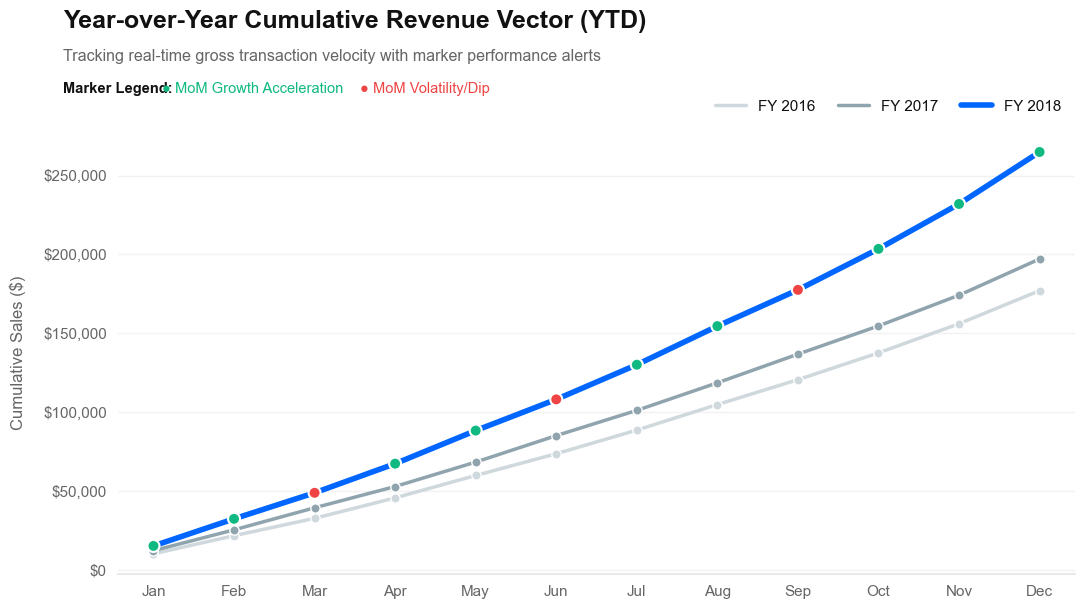

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np


# ----------------------------------------------------------------------------

# ==================================================================
# 1. DATA PROCESSING & CONDITIONAL CONTEXT
# ==================================================================
df['sales_year'] = df['sales_year'].astype(int)
unique_years = sorted(df['sales_year'].unique())
max_year = max(unique_years)

# ==================================================================
# 2. DESIGN SYSTEM & CORPORATE THEME
# ==================================================================
sns.set_theme(style="white", context="notebook")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Inter', 'Arial', 'Helvetica', 'Segoe UI']

fig, ax = plt.subplots(figsize=(11, 6.5), facecolor='white')
ax.set_facecolor('white')

color_palette = {
    2016: '#CFD8DC',  # Light Slate Gray
    2017: '#90A4AE',  # Medium Slate Gray
    2018: '#0066FF'   # Premium Electric Blue
}

# ==================================================================
# 3. LAYERED GRAPHICS ENGINE WITH CONDITIONAL MARKERS
# ==================================================================
for year in unique_years:
    year_df = df[df['sales_year'] == year].copy()
    is_active = (year == max_year)
    
    line_color = color_palette.get(year, '#B0BEC5')
    line_width = 4.0 if is_active else 2.5
    z_layer = 5 if is_active else 3
    
    # Step A: Draw the core vector line trajectory without standard markers
    ax.plot(
        year_df['month_name'],
        year_df['cumulative_sales'],
        label=f"FY {year}",
        color=line_color,
        linewidth=line_width,
        zorder=z_layer
    )
    
    # Step B: Inject conditional formatting logic onto the marker layer
    if is_active:
        # Business Logic: Evaluate if monthly performance accelerated or dipped MoM
        year_df['mom_velocity'] = year_df['monthly_sales'].diff().fillna(0)
        
        # Assign colors conditionally based on direction vector
        marker_colors = [
            '#10B981' if velocity >= 0 else '#EF4444' 
            for velocity in year_df['mom_velocity']
        ]
        
        # Overlay the high-fidelity conditional scatter markers
        ax.scatter(
            year_df['month_name'],
            year_df['cumulative_sales'],
            c=marker_colors,
            s=75,
            edgecolors='white',
            linewidths=1.5,
            zorder=z_layer + 1  # Ensures scatter points sit perfectly on top
        )
    else:
        # Historical context markers remain clean and uniform to preserve focus
        ax.scatter(
            year_df['month_name'],
            year_df['cumulative_sales'],
            color=line_color,
            s=45,
            edgecolors='white',
            linewidths=1,
            zorder=z_layer + 1
        )

ax.set_xmargin(0.04)

# ==================================================================
# 4. TYPOGRAPHY, GRIDLINES & LAYOUT CLEANING
# ==================================================================
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"${x:,.0f}"))
ax.tick_params(axis='x', colors='#666666', labelsize=11, length=0, pad=8)
ax.tick_params(axis='y', colors='#666666', labelsize=11, length=0, pad=8)

ax.set_axisbelow(True)
ax.yaxis.grid(True, color='#F2F2F2', linestyle='-', linewidth=1, zorder=0)

sns.despine(left=True, top=True, right=True, bottom=False, ax=ax)
ax.spines['bottom'].set_color('#EAEAEA')
ax.spines['bottom'].set_linewidth(1.5)

ax.set_ylabel("Cumulative Sales ($)", color='#666666', fontsize=12, fontweight='medium', labelpad=12)

# ==================================================================
# 5. LEGEND & BUSINESS INFOGRAPHIC KEY
# ==================================================================
ax.legend(
    loc='lower right',
    bbox_to_anchor=(1.0, 1.01),
    ncol=3,
    frameon=False,
    fontsize=11,
    labelcolor='#111111',
    columnspacing=1.5
)

# Adding inline business legend indicator flags for the conditional formatting colors
fig.text(0.04, 0.84, "Marker Legend:", fontsize=10.5, fontweight='bold', color='#111111')
fig.text(0.13, 0.84, "● MoM Growth Acceleration", fontsize=10.5, color='#10B981')
fig.text(0.31, 0.84, "● MoM Volatility/Dip", fontsize=10.5, color='#EF4444')

# ==================================================================
# 6. HEADER ARCHITECTURE & RENDER PACKAGING
# ==================================================================
fig.text(
    0.04, 0.94, "Year-over-Year Cumulative Revenue Vector (YTD)", 
    fontsize=18, fontweight='bold', color='#111111', ha='left'
)
fig.text(
    0.04, 0.89, "Tracking real-time gross transaction velocity with marker performance alerts", 
    fontsize=11.5, color='#666666', ha='left'
)

plt.subplots_adjust(left=0.09, right=0.96, top=0.78, bottom=0.10)
plt.show()

3. Calculate the year-over-year growth rate of total sales.

In [ ]:
query = """
WITH yearly_sales AS (
    SELECT
        -- MySQL Specific: Use DATETIME for casting text, then extract the year
        YEAR(CAST(o.order_purchase_timestamp AS DATETIME)) AS sales_year,
        SUM(p.payment_value) AS total_sales
    FROM ecommerce.orders o
    JOIN ecommerce.payments p 
        ON o.order_id = p.order_id
    WHERE 
        o.order_status NOT IN ('canceled', 'unavailable')
    GROUP BY 1
)
SELECT
    sales_year,
    -- MySQL Specific: ROUND works directly on floats; no extra CAST needed
    ROUND(total_sales, 2) AS current_year_sales,
    ROUND(LAG(total_sales) OVER (ORDER BY sales_year), 2) AS previous_year_sales,
    -- Calculating YoY Growth Rate percentage
    ROUND(
        (total_sales - LAG(total_sales) OVER (ORDER BY sales_year)) 
        / LAG(total_sales) OVER (ORDER BY sales_year) * 100, 
        2
    ) AS yoy_growth_rate_pct
FROM yearly_sales
ORDER BY sales_year;"""

cursor.execute(query)
data = cursor.fetchall()

# Projects cleanly into your original 4-column structure
df = pd.DataFrame(data, columns=['sales_year', 'current_year_sales', 'previous_year_sales', 'yoy_growth_rate_pct'])
df.head()

,sales_year,current_year_sales,previous_year_sales,yoy_growth_rate_pct
0,2016,51813.38,NaN,NaN
1,2017,7092491.65,51813.38,13588.53
2,2018,8594831.98,7092491.65,21.18


4. Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [3]:
query = """
WITH processed_purchases AS (
    SELECT 
        c.customer_unique_id,
        CAST(o.order_purchase_timestamp AS DATETIME) AS purchase_date,
        -- Window Function 1: Find first purchase date per customer instantly
        MIN(CAST(o.order_purchase_timestamp AS DATETIME)) OVER(PARTITION BY c.customer_unique_id) AS first_purchase_date,
        -- Window Function 2: Find global max date for data maturity verification
        MAX(CAST(o.order_purchase_timestamp AS DATETIME)) OVER() AS max_dataset_date
    FROM ecommerce.orders o
    JOIN ecommerce.customers c 
        ON o.customer_id = c.customer_id
    WHERE o.order_status NOT IN ('canceled', 'unavailable')
),
customer_retention_states AS (
    SELECT 
        customer_unique_id,
        -- Evaluate retention at the row level, then collapse via MAX()
        MAX(CASE WHEN purchase_date > first_purchase_date 
                  AND purchase_date <= DATE_ADD(first_purchase_date, INTERVAL 6 MONTH) 
             THEN 1 ELSE 0 END) AS is_retained
    FROM processed_purchases
    -- Apply the maturity guardrail directly to the pipeline stream
    WHERE first_purchase_date <= DATE_SUB(max_dataset_date, INTERVAL 6 MONTH)
    GROUP BY customer_unique_id
)
SELECT 
    COUNT(*) AS total_eligible_cohort_size,
    SUM(is_retained) AS total_retained_customers,
    ROUND((SUM(is_retained) / COUNT(*)) * 100, 2) AS six_month_retention_rate_pct
FROM customer_retention_states;
"""

cursor.execute(query)
data = cursor.fetchall()
# Projects cleanly into your original 3-column structure
df = pd.DataFrame(data, columns=['total_eligible_cohort_size', 'total_retained_customers', 'six_month_retention_rate_pct'])
df.head()



,total_eligible_cohort_size,total_retained_customers,six_month_retention_rate_pct
0,57168,1632,2.85


5. Identify the top 3 customers who spent the most money in each year.

In [59]:
query = """
WITH customer_yearly_spending AS (
    -- Step 1: Aggregate revenue by individual customer identity per year
    SELECT
        YEAR(CAST(o.order_purchase_timestamp AS DATETIME)) AS sales_year,
        c.customer_unique_id,
        SUM(p.payment_value) AS total_spent
    FROM ecommerce.orders o
    JOIN ecommerce.payments p 
        ON o.order_id = p.order_id
    JOIN ecommerce.customers c 
        ON o.customer_id = c.customer_id
    WHERE 
        -- Business Rigor: Filter out unpaid or aborted transactions
        o.order_status NOT IN ('canceled', 'unavailable')
    GROUP BY 1, 2
),
ranked_customers AS (
    -- Step 2: Dynamically rank spenders within their respective fiscal buckets
    SELECT
        sales_year,
        customer_unique_id,
        total_spent,
        -- ROW_NUMBER ensures a strict 'Top 3' cutoff for executive reporting
        ROW_NUMBER() OVER (
            PARTITION BY sales_year 
            ORDER BY total_spent DESC
        ) AS spending_rank
    FROM customer_yearly_spending
)
-- Step 3: Extract the elite cohorts
SELECT
    sales_year,
    spending_rank,
    customer_unique_id,
    ROUND(total_spent, 2) AS total_money_spent
FROM ranked_customers
WHERE spending_rank <= 3
ORDER BY sales_year DESC, spending_rank ASC;
"""

cursor.execute(query)
data = cursor.fetchall()
# Projects cleanly into your original 3-column structure
df = pd.DataFrame(data, columns=['sales_year', 'spending_rank', 'customer_unique_id', 'total_money_spent'])
df.head(10)


,sales_year,spending_rank,customer_unique_id,total_money_spent
0,2018,1,763c8b1c9c68a0229c42c9fc6f662b93,7274.88
1,2018,2,459bef486812aa25204be022145caa62,6922.21
2,2018,3,48e1ac109decbb87765a3eade6854098,4681.78
3,2017,1,0a0a92112bd4c708ca5fde585afaa872,13664.08
4,2017,2,da122df9eeddfedc1dc1f5349a1a690c,7571.63
5,2017,3,dc4802a71eae9be1dd28f5d788ceb526,6929.31
6,2016,1,fdaa290acb9eeacb66fa7f979baa6803,1423.55
7,2016,2,40b41ade17bb2121b576b07e25ce622b,982.41
8,2016,3,cfbb7c1c3d613d974eef515b180e2c9b,979.91


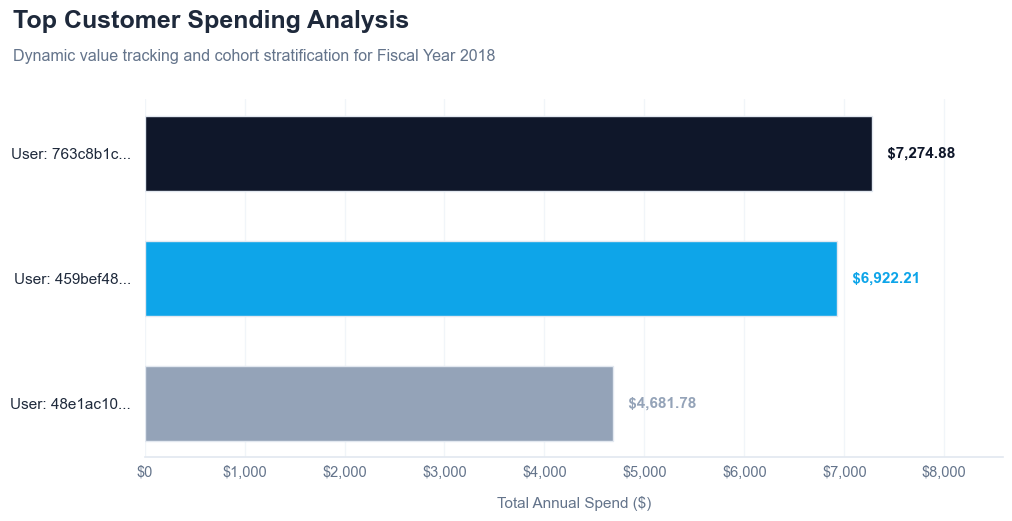

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# --- Production-Grade Mock Data Shell (Uncomment to test out-of-the-box) ---
# data = {
#     'customer_unique_id': [f"usr_hash_{i}xyz789" for i in range(1, 11)] * 2,
#     'sales_year': [2025]*10 + [2024]*10,
#     'total_money_spent': [9500, 8200, 6100, 5400, 4900, 4100, 3800, 2900, 2100, 1500] + [8100, 7500, 5900, 5100, 4200, 3900, 3100, 2500, 1900, 1100],
#     'spending_rank': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] * 2
# }
# df = pd.DataFrame(data)
# --------------------------------------------------------------------------

# ==========================================
# STEP 1: CONFIGURATION & DATA PROCESSING
# ==========================================
# ENTERPRISE TOGGLE: Change this to view different year cohorts
TARGET_YEAR = df['sales_year'].max() 

df_plot = df.copy()
df_plot['total_money_spent'] = pd.to_numeric(df_plot['total_money_spent'], errors='coerce')
df_plot['spending_rank'] = pd.to_numeric(df_plot['spending_rank'], errors='coerce').astype(int)

# Filter for our active target cohort year
year_data = df_plot[df_plot['sales_year'] == TARGET_YEAR].copy()

# Sort ascending by spend so that Rank 1 plots flawlessly at the top of the horizontal bars
year_data = year_data.sort_values(by='total_money_spent', ascending=True)

# Clean UI ID formatting
year_data['display_id'] = "User: " + year_data['customer_unique_id'].astype(str).str[:8] + "..."

# DYNAMIC CONDITIONAL FORMATTING DICTIONARY
COLOR_METRIC = {
    1: '#0F172A',  # Slate 900 (Ultra Deep Navy for Absolute Top Spender)
    2: '#0EA5E9',  # Sky 500   (Vibrant Cyan/Blue for Runner Up)
    3: '#94A3B8'   # Slate 400 (Muted Grey for Third Place)
}
# Map colors row-by-row, defaulting remaining cohorts to Slate 400
dynamic_colors = year_data['spending_rank'].map(lambda x: COLOR_METRIC.get(x, '#94A3B8')).tolist()


# ==========================================
# STEP 2: CANVAS INITIALIZATION & DESIGN SYSTEM
# ==========================================
sns.set_theme(style="white", context="notebook")

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Inter', 'Arial', 'Helvetica', 'Segoe UI']

fig, ax = plt.subplots(figsize=(11, 5.5), facecolor='white')
ax.set_facecolor('white')


# ==========================================
# STEP 3: GRAPHICAL CONSTRUCTION (Horizontal Bars)
# ==========================================
bars = ax.barh(
    year_data['display_id'],
    year_data['total_money_spent'],
    color=dynamic_colors,
    edgecolor='#E2E8F0',
    linewidth=1.0,
    height=0.60,  # Emulates the clean bar gap ratios
    zorder=3
)

# Allocate safe margin padding to protect outside numbers from clipping
ax.set_xlim(0, year_data['total_money_spent'].max() * 1.18)


# ==========================================
# STEP 4: AXIS TYPOGRAPHY & LAYOUT CLEANING
# ==========================================
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"${x:,.0f}"))
ax.tick_params(axis='x', colors='#64748B', labelsize=10.5, length=0, pad=6)
ax.tick_params(axis='y', colors='#1E293B', labelsize=11, length=0, pad=10)

# Structural Grid Setup (Tucked neatly behind data layout)
ax.set_axisbelow(True)
ax.xaxis.grid(True, color='#F1F5F9', linestyle='-', linewidth=1, zorder=0)
ax.yaxis.grid(False)

# Strip framing lines, keep a clean baseline anchor boundary
sns.despine(left=True, top=True, right=True, bottom=False, ax=ax)
ax.spines['bottom'].set_color('#E2E8F0')
ax.spines['bottom'].set_linewidth(1.2)

ax.set_xlabel("Total Annual Spend ($)", color='#64748B', fontsize=11, labelpad=12)


# ==========================================
# STEP 5: DYNAMIC DATA LABELS (Matching Bar Colors)
# ==========================================
labels = ax.bar_label(
    bars, 
    labels=[f" ${x:,.2f}" for x in year_data['total_money_spent']], 
    padding=8, 
    fontsize=11,
    fontweight='bold'
)

# Engineering Override: Force label font colors to match their respective data bar fills
for label, color in zip(labels, dynamic_colors):
    label.set_color(color)


# ==========================================
# STEP 6: HEADER ARCHITECTURE & RENDER PACKAGING
# ==========================================
fig.text(
    0.04, 0.93, "Top Customer Spending Analysis", 
    fontsize=18, fontweight='bold', color='#1E293B', ha='left'
)
fig.text(
    0.04, 0.87, f"Dynamic value tracking and cohort stratification for Fiscal Year {TARGET_YEAR}", 
    fontsize=11.5, color='#64748B', ha='left'
)

# Set precise internal alignment layout bounds
plt.subplots_adjust(left=0.16, right=0.94, top=0.80, bottom=0.15)

plt.show()